In [115]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tp
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models

In [116]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [117]:
class_names=[
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [118]:
print("Training data shape :", x_train.shape)

Training data shape : (60000, 28, 28)


In [119]:
print("Training labels shape :", y_train.shape)

Training labels shape : (60000,)


In [120]:
print("Testing data shape :", x_test.shape)

Testing data shape : (10000, 28, 28)


In [121]:
print("Testing labels shape :", y_test.shape)

Testing labels shape : (10000,)


In [122]:
print("Unique labels        :", np.unique(y_train))
print("Pixel value range    : [", x_train.min(), ",", x_train.max(), "]")

Unique labels        : [0 1 2 3 4 5 6 7 8 9]
Pixel value range    : [ 0 , 255 ]


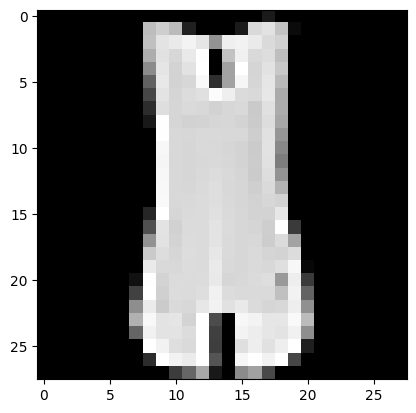

In [123]:
plt.imshow(x_train[4], cmap="gray")
plt.show()

In [124]:
print(y_train[0])

9


In [125]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [126]:
model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

In [127]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [128]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8212 - loss: 0.5113 - val_accuracy: 0.8462 - val_loss: 0.4466
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8629 - loss: 0.3834 - val_accuracy: 0.8690 - val_loss: 0.3676
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8760 - loss: 0.3448 - val_accuracy: 0.8753 - val_loss: 0.3498
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8813 - loss: 0.3208 - val_accuracy: 0.8681 - val_loss: 0.3690
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8911 - loss: 0.3001 - val_accuracy: 0.8779 - val_loss: 0.3389
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8933 - loss: 0.2889 - val_accuracy: 0.8860 - val_loss: 0.3244
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8976 - loss: 0.2751 - val_accuracy: 0.8873 - val_loss: 0.3139
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9017 - loss: 0.2633 

In [129]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest Loss    : {test_loss:}")
print(f"Test Accuracy: {test_acc:}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8821 - loss: 0.3573

Test Loss    : 0.3573095500469208
Test Accuracy: 0.882099986076355


In [130]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [131]:
predicted = np.argmax(predictions[0])
actual = y_test[0]
print(predicted)
print(actual)

9
9


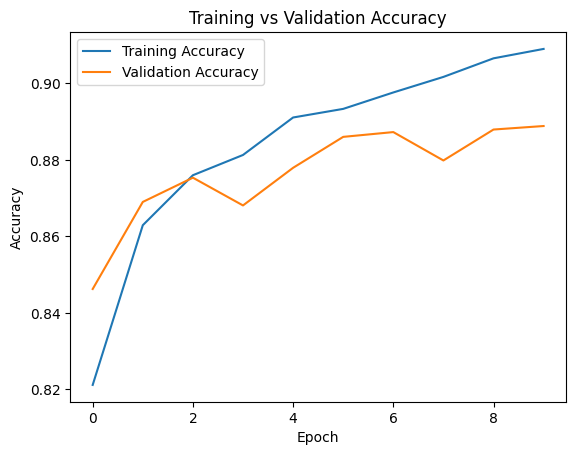

In [136]:

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

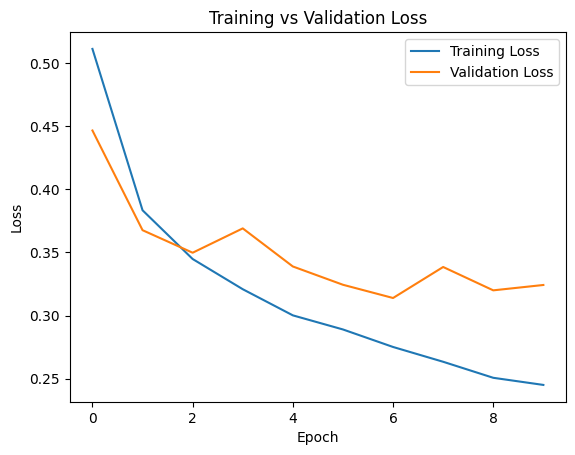

In [137]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [138]:
predictions = model.predict(x_test[:10], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

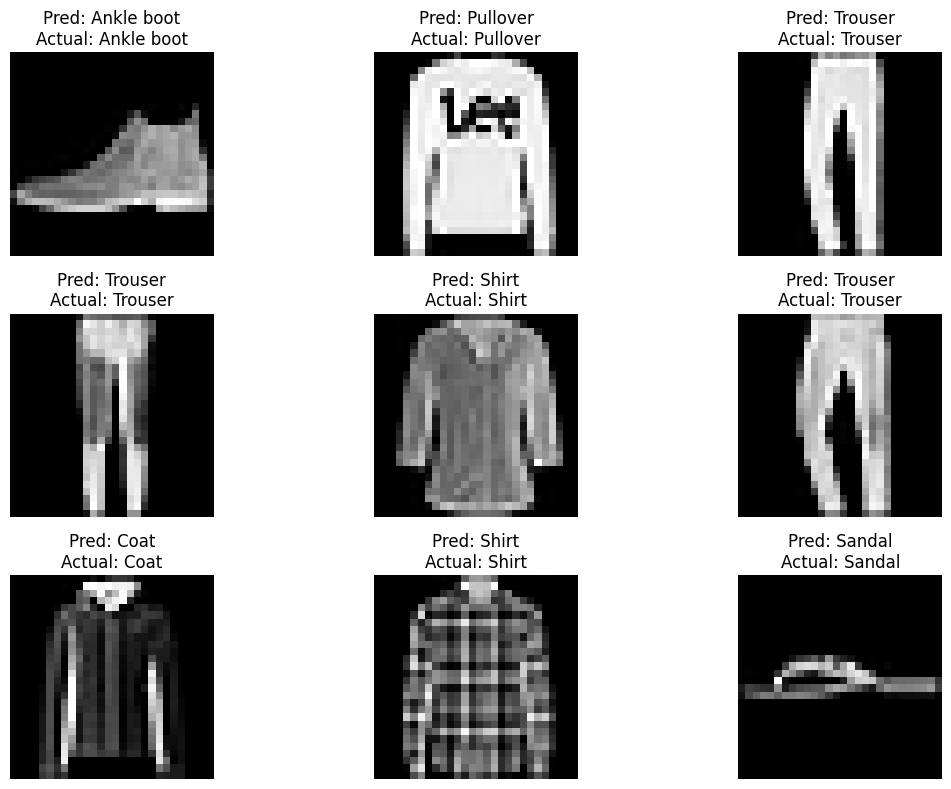

In [146]:
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.axis("off")

    predicted_label = np.argmax(predictions[i])
    actual_label = y_test[i]
    plt.title(
        f"Pred: {class_names[predicted_label]}\n"
        f"Actual: {class_names[actual_label]}"
    )
plt.savefig("Predictions.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()